<img src="./logo_UTN.svg" align="right" width="150" /> 

### Teoría de Circuitos II

# Trabajo Semanal N°2

Autor: *Olea Gasalla Ignacio Ezequiel*

*Fecha de entrega: martes 26 de mayo de 2026*

#### **Consigna** 
[👉  Hallar la transferencia $T=\frac{V_o}{V_i}$ en función de $\omega_0$ y $Q$.](#oft) 

[👉  Hallar los parámetros $\omega_0$, $Q$ y $k$.](#hlp) 

[👉  Cómo podría obtener un circuito pasabanda con los mismos componentes originales y con qué parámetros quedaría diseñado ( Ver ejemplo 4.6 en Schaumann , pag. 159 ).](#cpb) 

[👉 Se pide implementar un filtro pasabajos Chebyshev que cumpla con la siguiente plantilla. Debera interconectar mas de una red como la aquí presentada en configuración cascada. De ser necesario incluya una red de orden 1 pasabajos RC.](#fpc) 

##### **Bonus**:

[💎 Obtener los valores de la red normalizados en frecuencia e impedancia.](#vna) 

[💎 Simulación en Python de la Transferencia normalizada.](#stn) 

[💎 Simulación Circuital de la red con los valores normalizados. Simule la respuesta de modulo en forma paramétrica convenientemente para graficar curvas pasabanda con Q: 1:100 en pasos de 10.](#src) 

In [239]:
IFrame("./tc2_ts2.pdf", width=1000, height=1000)

In [195]:
# Importo las librerias
import math
import sympy as sp
import numpy as np
import scipy.signal as sig
from sympy import Eq
from IPython.display import display, IFrame, Math
from matplotlib import pyplot as plt
from scipy.signal import TransferFunction

from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot, pretty_print_SOS, tf2sos_analog, pretty_print_bicuad_omegayq,tf2zpk, parametrize_sos, analyze_sys
from pytc2.general import s, w, print_latex, a_equal_b_latex_s, print_subtitle, Chebyshev_polynomials

<a id="oft"></a>
#### **Obtención de la Función Transferencia**
 En los siguiente dos códigos, verifico la transferencia obtenida en el papel y la gráfico, se paso, obteniendo los valores de los componentes correspondientes:

In [58]:
# Declaro qué es variable, componente y tensiones.
s = sp.symbols('s')
C, R1, R2, R3, R4 = sp.symbols('C R1 R2 R3 R4', positive=True, real=True)
Vi, Vo, Vx = sp.symbols('Vi Vo Vx')

# Agrego las ecuaciones de nodos
eq1 = -Vx/R3 +Vo*s*C
eq2 = -Vi/R1 -Vx*s*C -Vx/R2 -Vo/R3
sol = sp.solve([eq1, eq2], (Vx, Vo))

# Armo la transferencia y la presento 
H = sp.simplify(sol[Vo] / Vi) 
display(Eq(sp.Function('T')(s), H))

Eq(T(s), -R2*R3/(R1*(C**2*R2*R3**2*s**2 + C*R3**2*s + R2)))

Los valores a usar para w0 = 1.0 rad/s , Q = 100.0 y K = 1.0 son:
   R1 = 1.0 Ω 
   R2 = 100.0 Ω 
   R3 = 1.0 Ω 
   C = 1.0 F


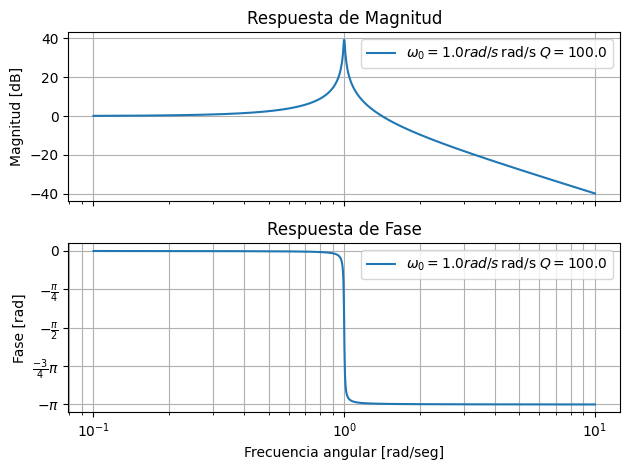

In [240]:
# Función para mostrar en formato de ingenieria las unidades
def eng_format(value, unit=""):
    import numpy as np
    if value == 0:
        return f"0 {unit}"
    exp = int(np.floor(np.log10(abs(value)) / 3) * 3)
    scaled = value / (10**exp)
    prefixes = {-12: "p",-9: "n",-6: "u",-3: "m",0: "",3: "k",6: "M",9: "G"}
    prefix = prefixes.get(exp, f"e{exp}")
    return f"{scaled:.1f} {prefix}{unit}"

#--------------------------------------------------------------------------

# Valor de R3 y valores de w0, Q y K queridos:
R3 = 1
w0 = 1
Q  = 100
K  = 1 # No se toma en cuenta el desfase de K

# Proceso inverso por el que se obtiene w0, Q y K
R1 = R3 / K
R2 = Q * R3
C = 1 / (R3*w0)

my_tf = TransferFunction( [ 1/(R1*R3*(C**2)) ], [1, 1/(R2*C) , 1/(C*R3)] )
bodePlot(my_tf, fig_id=1, filter_description = rf"$\omega_0 = {eng_format(w0, "rad/s")}\,\mathrm{{rad/s}}\; Q = {Q:.1f}$" )

print(rf"Los valores a usar para w0 = {eng_format(w0, "rad/s")} , Q = {Q:.1f} y K = {K:.1f} son:")
print(rf"   R1 = {eng_format(R1, 'Ω')} ")
print(rf"   R2 = {eng_format(R2, 'Ω')} ")
print(rf"   R3 = {eng_format(R3, 'Ω')} ")
print(rf"   C = {eng_format(C, 'F')}")

plt.figure(1)
plt.tight_layout()
plt.autoscale()
plt.grid(True, which="minor")

<a id="hlp"></a>
#### **Hallar los parámetros**
 El siguiente scrip permite obtener los parametros $\omega_0$, $Q$ y $K$ usando los valores de componentes:

In [215]:
# Valores de componentes:
R1 = 1e3
R2 = 5e3
R3 = 1e3
C = 318.3e-9

# Proceso inverso por el que se obtiene w0, Q y K
w0 = 1/(C*R3)
Q = R2/R3
K = R3/R1

print(rf"Los valores de w0, Q y K  son:")
print(rf"   w0 = {eng_format(w0, "rad/s")} ")
print(rf"   Q = {eng_format(Q, "")} ")
print(rf"   K = {eng_format(K, "")} ")

Los valores de w0, Q y K  son:
   w0 = 3.1 krad/s 
   Q = 5.0  
   K = 1.0  


<a id="cpb"></a>
#### **Circuito Pasa Banda**
 El siguiente scrip verifica el valor de transferencia obtenido.

In [212]:
# Declaro qué es variable, componente y tensiones.
s = sp.symbols('s')
C, R1, R2, R3, R4 = sp.symbols('C R1 R2 R3 R4', positive=True, real=True)
Vi, Vo, Vx = sp.symbols('Vi Vo Vx') # Vx = Vx2 = -Vx1

# Agrego las ecuaciones de nodos
eq1 = Vo/R3 + Vx*s*C
eq2 = Vi/R1 + (1/R2 + s*C)*Vo - Vx/R3
sol = sp.solve([eq1, eq2], (Vx, Vo))

# Armo la transferencia y la presento 
H = sp.simplify(sol[Vo] / Vi) 
display(Eq(sp.Function('T')(s), H))

Eq(T(s), -C*R2*R3**2*s/(R1*(C**2*R2*R3**2*s**2 + C*R3**2*s + R2)))

<a id="fpc"></a>
#### **Filtro Pasabajos Chebyshev**
 El siguiente scrip utiliza el valor del ripple y el orden del filtro para calcular el filtro de Chebyshev. El resultado da el modulo al cuadrado de la transferencia del filtro, la segunda parte analiza los coeficientes para quedarme con la transferencia que tiene los polos en el lado izquierdo del eje jw en el plano Laplace, por ultimo, la gráfica.

Eq(|T_{Cheby}|^2(s), -0.0404884228370383/(1.0*s**10 + 2.5*s**8 + 2.1875*s**6 + 0.78125*s**4 + 0.09765625*s**2 - 0.0404884228370383))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

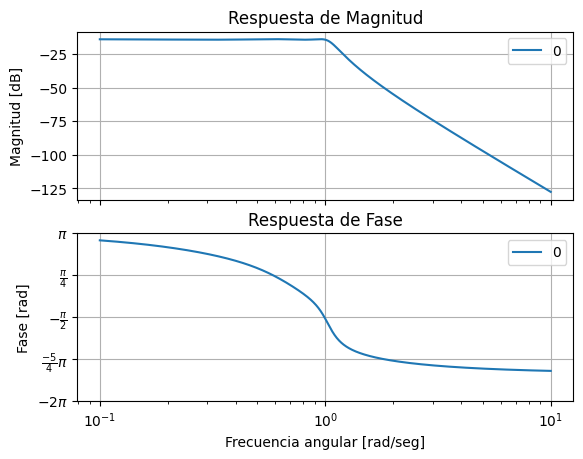

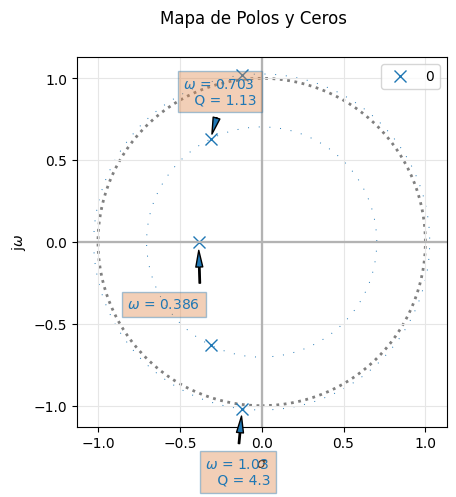

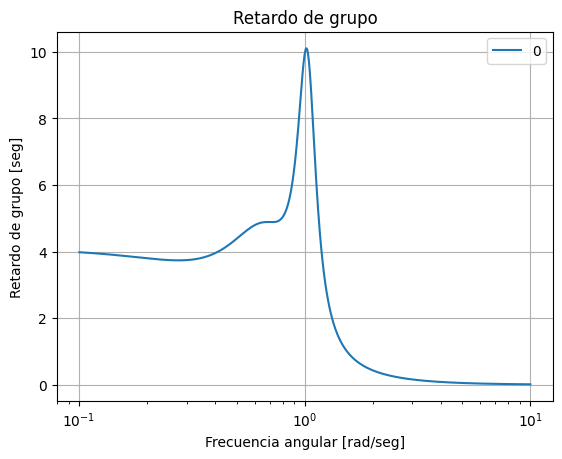

In [237]:
# Elijo el orden y ripple que necesito
order  = 5
ripple = 0.4

# Calculo el epsilon 
eps = np.sqrt( 10**(ripple/10) - 1 )

# Calculo el módulo de la Transferencia al cuadrado en función de 's'
T = sp.expand(1 + eps**2 * (sp.expand(Chebyshev_polynomials(order)))**2)
w_ = list(T.free_symbols)[0] # Permite que .subs funcione 
T = T.subs(w_, s/sp.I)

# Dejo mónico el polinomio 
T_poly = sp.Poly(T, s)
cp = T_poly.LC()
T = (1/cp) / (T/cp)

display(Eq(sp.Function("|T_{Cheby}|^2")(s), T))

#----------------------------------------------------------------------------------------------------------------------

# Asigno los valores del módulo de la transferencia al cuadrado 
num = -0.0404884228370383
den = np.array([1, 0, 2.5, 0, 2.1875, 0, 0.78125, 0 , 0.09765625, 0 , -0.0404884228370383])

# Calculo sus polos y me quedo solo con los que están en el lado izquierdo del eje jw del plano Laplace
cheby_roots = np.roots(den)
cheby_roots = cheby_roots[ np.real(cheby_roots) < 0 ]

# Consigo la Función Transferencia
z = []
p = cheby_roots
k = num
num, den = sig.zpk2tf(z,p,k)
mi_tf = sig.TransferFunction(num,den)


analyze_sys( mi_tf )
this_sos = tf2sos_analog(num, den)
display(Math(r"T_{Cheby}(s)=", a))
pretty_print_SOS(this_sos, mode='omegayq')

pretty_print_lti(num,den)

<a id="vna"></a>
#### **Valores normalizados del filtro Ackerberg-Mossberg de segundo orden**
 Con el analisís anterior, sabemos que $\omega_0=\frac{1}{CR_3}$ por lo que si queremos normalizar en frecuencia, la norma debe ser $n_w=\omega_0=\frac{1}{CR_3}$ lo que quiere decir que la nueva $\omega_0$ sera igual a 1 por lo que la relación de los componentes queda $C = \frac{1}{R_3}$. Si elijo que la norma de impedancia sea igual a R3 ($n_z=R_3$), entonces $R_{3 (normalizado)}=1$ y $C_{(normalizado)}=1$.
 
Resumiendo:
 \begin{equation}
\begin{cases} 
n_w = w_0 = \frac{1}{CR3} \\\\
n_z = R_3
\end{cases}
,
\begin{cases} 
C' = 1 \\\\
R_1' = \frac{R_1}{R_3} \\\\
R_2' = \frac{R_2}{R_3} \\\\
R_3' = 1
\end{cases}
\end{equation}

<a id="stn"></a>
#### **Simulación de la transferencia normalizada**
 En el siguiente scrip se muestra la transferencia normalizada donde elegí que la norma de impedancia sea R3 y que la norma de frecuencia sea $\omega_0$. Están anotados los componentes normalizados junto con la transferencia resultante.

In [235]:
# Declaro qué es variable, componente y tensiones.
s = sp.symbols('s')
C, R1, R2, R3, R4 = sp.symbols('C R1 R2 R3 R4', positive=True, real=True)
Vi, Vo, Vx = sp.symbols('Vi Vo Vx')

# Si nw = w0 => w0' = 1 r/s => C' = 1/R3'
# Si nz = R3 => 
    # C'  = 1
    # R1' = R1/R3
    # R2' = R2/R3 
    # R3' = 1

# Agrego las ecuaciones de nodos con componentes normalizados (C=1 y R3=1)
eq1 = -Vx + Vo*s
eq2 = -Vi/(R1) -Vx*s -Vx/(R2) -Vo
sol = sp.solve([eq1, eq2], (Vx, Vo))

# Armo la transferencia y la presento 
H = sp.simplify(sol[Vo] / Vi) 
display(Eq(sp.Function('T')(s), H))

Eq(T(s), -R2/(R1*(R2*s**2 + R2 + s)))

<a id="src"></a>
#### **Simulación de la red circuital**
 En LtSpice se simuló el circuito usando componentes de valor unitario. Si recordamos: $Q=\frac{R2}{R3}$ por lo que si $R3=1 => Q=R2$. Se pidió hacer un barrido cambiando el valor de Q y observando la Transferencia:

<img src="./circuit.png" /> 

<img src="./plot_circuit.png" /> 

 Se puede observar que a medida que el $Q$ aumenta, el sobrepico en $160mHz$ (Equivalente a $\omega_o = 1 \frac{'rad'}{s}$) aumenta con el $Q$, al igual que su ganancia en e